# Quickstart: ECMWF AIFS Single forecast, virtual - dynamical.org Icechunk Zarr

ECMWF's Artificial Intelligence Forecasting System (AIFS) is an AI based weather model that produces global forecasts. It generates 15-day forecasts at 0.25 degree resolution every 6 hours.

This is the **virtual** version of the archive: instead of copying the data, it stores byte-range references into ECMWF's original GRIB files and decodes them as you read. That makes it cheap to carry **every** variable ECMWF publishes — all 35, including the six on pressure levels — and optimizes it for spatial (map) access. For time series at a point across many forecasts, prefer the [materialized ECMWF AIFS Single forecast](https://dynamical.org/catalog/ecmwf-aifs-single-forecast/).

Dataset documentation: https://dynamical.org/catalog/ecmwf-aifs-single-forecast-virtual/

Note: `dynamical-catalog>=0.8.0` (or `zarr>=3.2 icechunk>=2.0 gribberish>=1.5`) is required.

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import os

os.environ.setdefault("DYNAMICAL_STAC_CATALOG_URL", "https://stac-staging.dynamical.org/catalog.json")

import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-aifs-single-forecast-virtual", chunks=None)
ds

<xarray.Dataset> Size: 51TB
Dimensions:                                                (init_time: 3447,
                                                            lead_time: 61,
                                                            latitude: 721,
                                                            longitude: 1440)
Coordinates:
  * init_time                                              (init_time) datetime64[ns] 28kB ...
    expected_forecast_length                               (init_time) timedelta64[us] 28kB ...
  * lead_time                                              (lead_time) timedelta64[us] 488B ...
    valid_time                                             (init_time, lead_time) datetime64[ns] 2MB ...
  * latitude                                               (latitude) float64 6kB ...
  * longitude                                              (longitude) float64 12kB ...
    spatial_ref                                            int64 8B ...
Data variables: (12/29)
    downward_long_wave_radiation_run_total_surface         (init_time, lead_time, latitude, longitude) float64 2TB ...
    dew_point_temperature_2m                               (init_time, lead_time, latitude, longitude) float64 2TB ...
    downward_short_wave_radiation_run_total_surface        (init_time, lead_time, latitude, longitude) float64 2TB ...
    convective_precipitation_run_total_surface             (init_time, lead_time, latitude, longitude) float64 2TB ...
    land_sea_mask_surface                                  (init_time, lead_time, latitude, longitude) float64 2TB ...
    geopotential_height_surface                            (init_time, lead_time, latitude, longitude) float64 2TB ...
    ...                                                     ...
    temperature_2m                                         (init_time, lead_time, latitude, longitude) float64 2TB ...
    volumetric_soil_moisture_layer_1                       (init_time, lead_time, latitude, longitude) float64 2TB ...
    wind_v_10m                                             (init_time, lead_time, latitude, longitude) float64 2TB ...
    wind_v_100m                                            (init_time, lead_time, latitude, longitude) float64 2TB ...
    wind_u_100m                                            (init_time, lead_time, latitude, longitude) float64 2TB ...
    total_column_water_atmosphere                          (init_time, lead_time, latitude, longitude) float64 2TB ...
Attributes:
    dataset_id:           ecmwf-aifs-single-forecast-virtual
    dataset_version:      0.1.0
    name:                 ECMWF AIFS Single forecast, virtual
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS Single forecast data processed by dynami...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

This is a forecast dataset with two time dimensions: `init_time` (when the forecast run began) and `lead_time` (how far ahead the forecast extends). The `valid_time` coordinate combines these to give the actual forecasted time. It also has `latitude` and `longitude` spatial dimensions on a global 0.25 degree grid.

Two things are worth knowing before you start:

- **One chunk is one global field.** Reading any single grid cell decodes the whole map behind it, so maps are cheap and a point series over one forecast is fine (61 fields, a few seconds), but scanning a point across thousands of `init_time`s is expensive.
- **Variables on pressure levels live in a group.** Surface and single-level variables are at the dataset root; the six variables carried on the 14 pressure levels are in the `pressure_level` group.

In [3]:
# Variables with a vertical dimension live in the pressure_level group
ds_pressure = dynamical_catalog.open(
    "ecmwf-aifs-single-forecast-virtual", group="pressure_level", chunks=None
)
ds_pressure

<xarray.Dataset> Size: 147TB
Dimensions:                   (init_time: 3447, lead_time: 61, latitude: 721,
                               longitude: 1440, pressure_level: 14)
Coordinates:
  * init_time                 (init_time) datetime64[ns] 28kB 2024-04-01 ... ...
    expected_forecast_length  (init_time) timedelta64[us] 28kB ...
  * lead_time                 (lead_time) timedelta64[us] 488B 0 days 00:00:0...
    valid_time                (init_time, lead_time) datetime64[ns] 2MB ...
  * latitude                  (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude                 (longitude) float64 12kB -180.0 -179.8 ... 179.8
  * pressure_level            (pressure_level) int64 112B 1000 925 850 ... 50 10
    spatial_ref               int64 8B ...
Data variables:
    specific_humidity         (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
    temperature               (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
    geopotential_height       (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
    wind_u                    (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
    wind_v                    (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
    vertical_velocity         (init_time, lead_time, latitude, longitude, pressure_level) float64 24TB ...
Attributes:
    dataset_id:           ecmwf-aifs-single-forecast-virtual
    dataset_version:      0.1.0
    name:                 ECMWF AIFS Single forecast, virtual
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS Single forecast data processed by dynami...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

### Accumulated variables are run totals

Precipitation, snowfall, runoff and the two downward radiation fields accumulate from the start of each forecast run, which is what `run_total` in their names means. So the value at lead time 15 days is the total for the whole forecast, and the amount falling in any window is the difference between its endpoints.

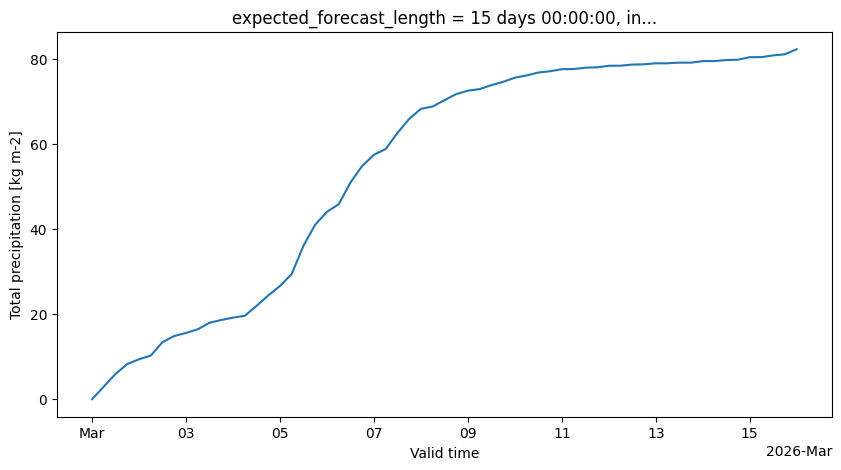

In [4]:
# 15-day precipitation forecast for Nairobi, Kenya
plot_ds = ds.sel(init_time="2026-03-01T00", latitude=-1.3, longitude=36.8, method="nearest")

accumulated = plot_ds["total_precipitation_run_total_surface"]
_ = accumulated.plot(x="valid_time", figsize=(10, 5))

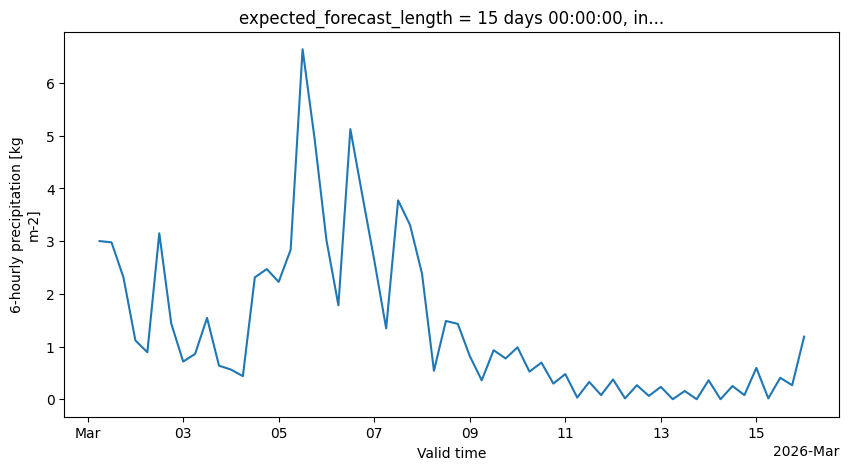

In [5]:
# Differencing the run total gives the precipitation falling in each 6 hour step
per_step = accumulated.diff("lead_time")
per_step.attrs["long_name"] = "6-hourly precipitation"
per_step.attrs["units"] = accumulated.attrs["units"]
_ = per_step.plot(x="valid_time", figsize=(10, 5))

### The large scale flow, 5 days ahead

Geopotential height on the 500 hPa surface reveals the ridges and troughs that steer weather systems. It comes from the `pressure_level` group.

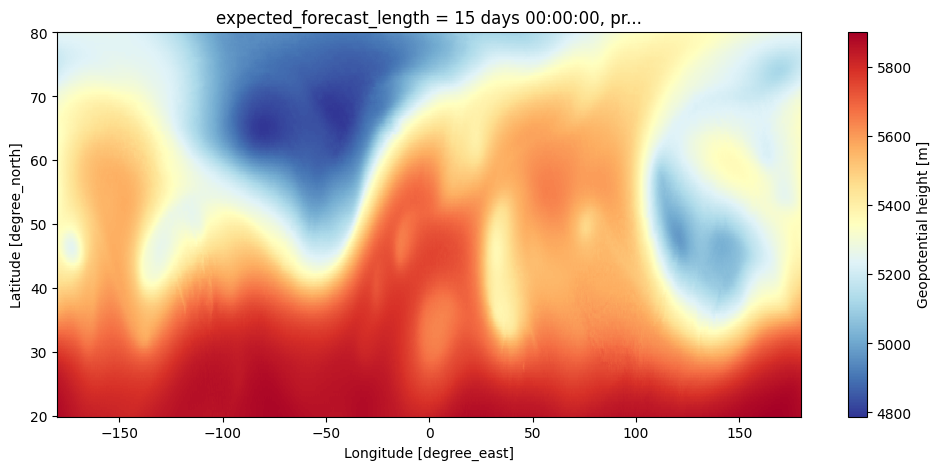

In [6]:
(
    ds_pressure["geopotential_height"]
    .sel(init_time="2025-02-01T00", lead_time="5d", pressure_level=500)
    .sel(latitude=slice(80, 20))
    .plot(figsize=(12, 5), cmap="RdYlBu_r")
)

### A slice through the atmosphere

The `pressure_level` group carries temperature, specific humidity, both wind components, vertical velocity and geopotential height on all 14 pressure levels — 84 fields per forecast step. Taking one line of longitude and plotting it against pressure gives a cross-section from pole to pole, where the tropopause is visible as the cold ceiling that sits high over the tropics and drops sharply toward the poles.

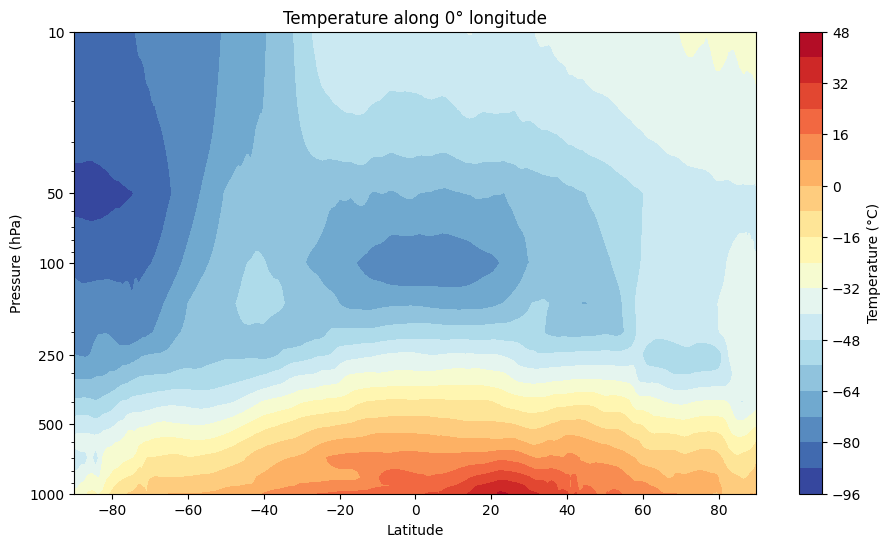

In [7]:
import matplotlib.pyplot as plt

# Temperature along the Greenwich meridian, from the surface to 10 hPa
cross_section = (
    ds_pressure["temperature"]
    .sel(init_time="2026-07-01T00", lead_time="24h")
    .sel(longitude=0.0, method="nearest")
    .load()
)

fig, ax = plt.subplots(figsize=(11, 6))
contours = ax.contourf(
    cross_section.latitude,
    cross_section.pressure_level,
    cross_section.transpose("pressure_level", "latitude"),
    levels=20,
    cmap="RdYlBu_r",
)
_ = ax.set_yscale("log")
_ = ax.invert_yaxis()
_ = ax.set_yticks([1000, 500, 250, 100, 50, 10])
_ = ax.set_yticklabels([1000, 500, 250, 100, 50, 10])
_ = ax.set(xlabel="Latitude", ylabel="Pressure (hPa)", title="Temperature along 0° longitude")
_ = fig.colorbar(contours, ax=ax, label="Temperature (°C)")

### Cloud in three layers

ECMWF reports cloud cover separately for low, medium and high altitudes as well as for the whole column. Splitting the three apart separates the shallow marine stratocumulus decks from the cirrus drawn out ahead of the mid-latitude storm tracks.

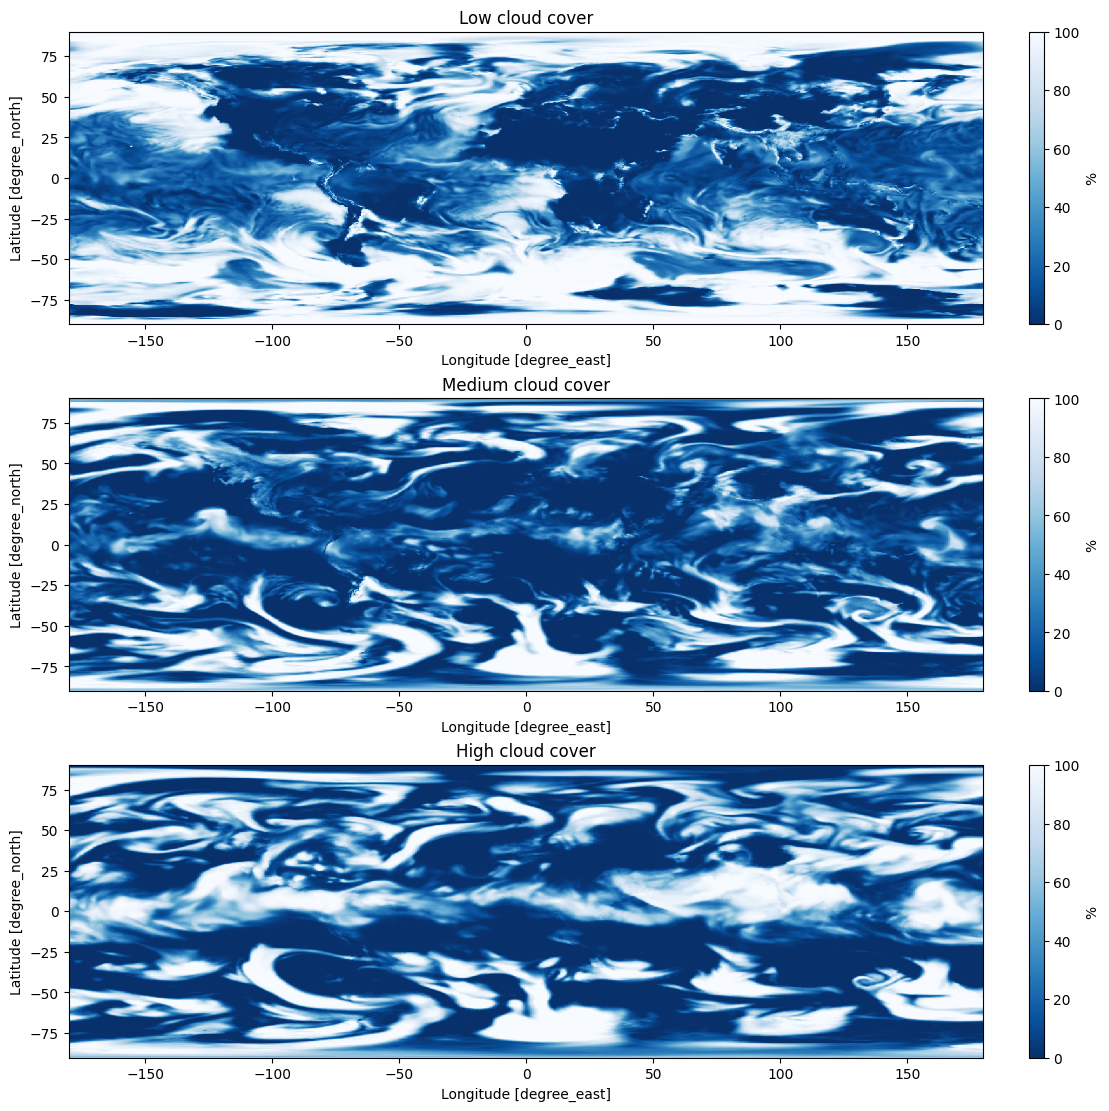

In [8]:
layers = (
    ("low_cloud_cover", "Low"),
    ("medium_cloud_cover", "Medium"),
    ("high_cloud_cover", "High"),
)

clouds = ds[[name for name, _ in layers]].sel(init_time="2026-07-01T00", lead_time="24h").load()

fig, axes = plt.subplots(3, 1, figsize=(11, 11), constrained_layout=True)
for ax, (name, label) in zip(axes, layers):
    clouds[name].plot(ax=ax, cmap="Blues_r", vmin=0, vmax=100, cbar_kwargs={"label": "%"})
    _ = ax.set_title(f"{label} cloud cover")

### How strong was the wind during Storm Éowyn?

Storm Éowyn struck Ireland and the UK on January 24, 2025 with record-breaking winds. We can compute 10m wind speed from the u and v components and map the storm's intensity.

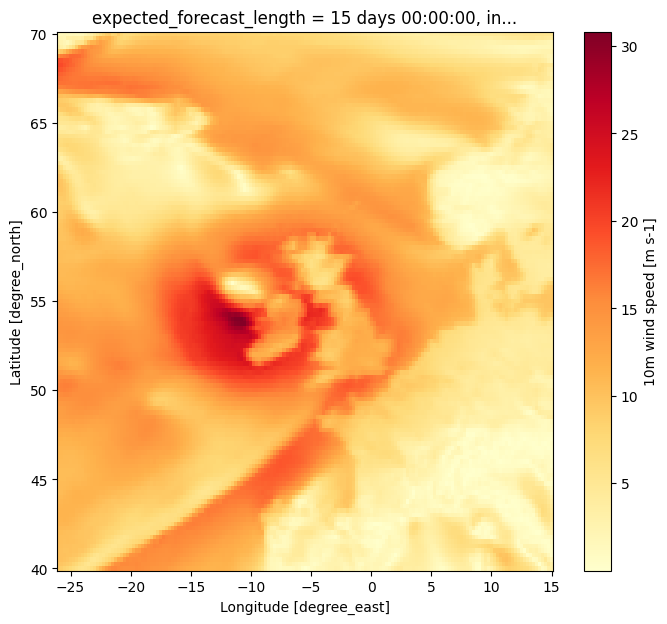

In [9]:
import numpy as np

# 10m wind speed over the British Isles, AIFS forecast initialized Jan 24 00Z, 6 hours ahead
plot_ds = ds.sel(
    init_time="2025-01-24T00",
    lead_time="6h",
    latitude=slice(70, 40),
    longitude=slice(-26, 15),
)

wind_speed = np.sqrt(plot_ds["wind_u_10m"]**2 + plot_ds["wind_v_10m"]**2)
wind_speed.attrs["units"] = "m s-1"
wind_speed.attrs["long_name"] = "10m wind speed"
wind_speed.plot(figsize=(8, 7), cmap="YlOrRd")

### Where is the coldest temperature forecast in the Northern Hemisphere right now?

Using the most recent forecast initialization, we can find the location with the lowest predicted 2m temperature over the next 24 hours.

Text(0.5, 1.0, 'Coldest 24h forecast: -16.0 °C at (69.8°, -37.5°)\nForecast initialized: 2026-08-10 12:00:00')

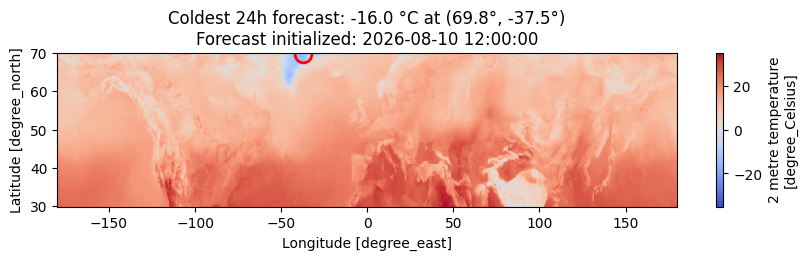

In [10]:
import pandas as pd

latest_init = ds.init_time[-1].values

cold_forecast = (
    ds["temperature_2m"]
    .sel(init_time=latest_init, lead_time=slice("0h", "23h"))
    .sel(latitude=slice(70, 30))  # Northern Hemisphere mid-latitudes
    .min(dim="lead_time")
    .load()
)

min_val = float(cold_forecast.min())
min_loc = cold_forecast.argmin(dim=["latitude", "longitude"])
min_lat = float(cold_forecast.latitude[min_loc["latitude"]])
min_lon = float(cold_forecast.longitude[min_loc["longitude"]])

fig, ax = plt.subplots(figsize=(10, 2))
cold_forecast.plot(ax=ax, cmap="coolwarm")
# Draw a red circle around the coldest point
ax.plot(min_lon, min_lat, "ro", markersize=12, markerfacecolor="none", markeredgewidth=2)
ax.set_title(f"Coldest 24h forecast: {min_val:.1f} °C at ({min_lat:.1f}°, {min_lon:.1f}°)\nForecast initialized: {pd.Timestamp(latest_init)}")

### Animated map

Total cloud cover traces weather systems as they sweep across the globe. Let's animate four days of forecast steps.

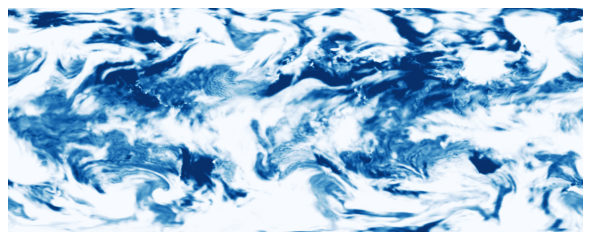

In [11]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Animation of total cloud cover over a week-long forecast
data = (
    ds["total_cloud_cover_atmosphere"]
    .sel(
        init_time="2026-03-01T00",
        lead_time=slice("6h", "4d"),
        latitude=slice(70, -70),
    )
    .load()
)

scale = 0.4
dpi = 80
fig, ax = plt.subplots(figsize=(data.longitude.size * scale / dpi, data.latitude.size * scale / dpi), dpi=dpi)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(lead_time=0), cmap="Blues_r", vmin=0, vmax=100)
anim = FuncAnimation(fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=200)

HTML(anim.to_jshtml())

### Community challenge

This archive carries every variable ECMWF publishes for AIFS Single, including fields the materialized dataset leaves out — soil temperature and moisture on two layers, the four cloud-cover fields, snow, runoff, and the full pressure-level suite.

Here are a few for inspiration:
- Build a vertical cross-section. Pull `temperature` and `specific_humidity` from the `pressure_level` group along a line of longitude and plot them against pressure to reveal fronts and the tropopause.
- Track a tropical cyclone by extracting minimum sea level pressure or maximum wind speed in a bounding box at each lead time (e.g. Typhoon Yagi, September 2024). How does the predicted storm track shift across initializations?
- Compare soil moisture in the two soil layers through a forecast of a heavy rain event. How far down does the wetting signal reach, and how quickly?

For point time series across many forecast initializations, the [materialized ECMWF AIFS Single forecast](https://dynamical.org/catalog/ecmwf-aifs-single-forecast/) is chunked for that access pattern.